# Case Study: Find the Z, using NRMSE-targeted configs

This reproduces the analysis in `ref/Case_Study_Find_the_Z.ipynb`, but instead of
manually picking four SPERR `bpp` values, it uses the compressor configurations
selected in `select_nrmse_targets.py`: for each of SZ3, SPERR, and zstd-trunc,
and for each order-of-magnitude category NRMSE ~ 10^0, 10^-1, ..., 10^-5, the
config with the best compression ratio anywhere in that decade, scanning the
*entire* `AnalysisJetsAuxDyn.pt/eta/phi` sweep in `data/results.csv` (not just
its Pareto frontier, which is an envelope over the whole NRMSE range and can
pass over the best point within a single decade).

Those configs were fit on jet branches. This notebook applies them, unchanged,
to the muon file's `lep_pt`/`lep_eta`/`lep_phi` (matched by name: pt->pt,
eta->eta, phi->phi) to see whether a rate-distortion operating point chosen on
one dataset actually transfers to another. `lep_e` has no jet-branch analogue
in the sweep, so it is left uncompressed throughout; only pt/eta/phi are put
through LossBench.

**Note:** producing this required fixing a real off-by-one bug in LossBench's
ROOT reader (`TTreeReader::SetEntry(0)` immediately followed by `Next()` was
silently dropping entry 0 of every branch read, corrupting the entry alignment
needed to zip pt/eta/phi/e back into four-vectors). It's fixed in
`~/LossBench/src/root-utils/root-utils.cpp` and the binary has been rebuilt.
This also means every existing sweep result (`data/results.csv` and the
`data/*-sweep/results.jsonl` files) was collected with entry 0 of each branch
excluded — negligible for aggregate statistics over 100k+ entries, but worth
knowing about.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

import uproot
import awkward as ak
import vector

REPO_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from constants import MUONS_FILENAME, MUONS_TREENAME
import fig6.run_case_study as case_study

OUTDIR = REPO_ROOT / "src" / "fig6" / "case_study_data"
TARGETS = sorted(case_study.TARGETS, reverse=True)
BRANCHES = ["pt", "eta", "phi"]
COMPRESSORS = ["sperr", "sz3", "zstd-trunc"]

## Select the best-compression config in each NRMSE decade

For each (branch, compressor), `best_at_order_of_magnitude` scans every config
in the jet sweep and, for each target decade [10^k, 10^(k+1)), keeps the one
with the highest compression ratio. If a (branch, compressor) never landed a
config in a given decade, that combination has no row and is dropped (visible
below as some `target_nrmse` groups having fewer than 3 branches).

Unlike the `config_note` strings in `data/nrmse_target_points.csv`,
`build_configs()` here keeps every compressor option from the matched row (not
just the "headline" parameter) so the SZ3 configs are reproduced exactly —
including cases where the matched row used an absolute rather than relative
error bound, which the `config_note` text mislabels.

In [2]:
configs = case_study.build_configs()
configs

,target_nrmse,branch,lep_branch,compressor,chunk_size,compressor_arg,achieved_nrmse,compression_ratio
0,0.00001,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=8.000000",0.000058,3.999404
1,0.00010,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=10.000000",0.000510,3.199618
2,0.00010,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=0.010000",0.000689,3.379087
3,0.00010,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.000932,7.997615
4,0.00100,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=0.100000",0.004479,4.701076
5,0.00100,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=0.100000",0.006886,5.120867
6,0.00100,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=2.000000",0.003663,15.990456
7,0.01000,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.030496,7.997615
8,0.01000,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.030133,7.997615
9,0.10000,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=2.000000",0.161029,15.990456


## Run LossBench

One LossBench invocation applies a single compressor config to every branch it's
given, but pt/eta/phi have different configs at a given target, so each
(compressor, target) needs one invocation per branch, all writing into the same
`--decompFile`. `run_case_study.main()` does this: 45 invocations total (3
branches x 3 compressors x 5 targets), writing results into
`src/fig6/case_study_data/`.

In [3]:
case_study.main()

Ran 36 lossbench invocations OK.
Configs: /home/ajbyrnes/lossbench-paper/src/fig6/case_study_data/lep_configs.csv
Results: /home/ajbyrnes/lossbench-paper/src/fig6/case_study_data/results.jsonl


## Look at results

Merge the achieved NRMSE/compression-ratio from the config-selection step
(computed on jet data) with the PSNR/compression-ratio LossBench actually
measured on the muon `lep_*` branches. The two can differ substantially,
since `lep_pt`/`lep_eta`/`lep_phi` don't have the same value distributions as
the jet branches the configs were chosen on.

In [4]:
raw = pd.read_json(OUTDIR / "results.jsonl", lines=True)
results = pd.json_normalize(raw.to_dict(orient="records"), sep=".")

# run_case_study.main() iterates `configs` in order and appends one result row
# per invocation, so row i of `results` corresponds exactly to row i of `configs`.
assert len(configs) == len(results)
assert (configs["lep_branch"].to_numpy() == results["config.branches"].to_numpy()).all()

df = pd.concat([configs, results[["results.psnr", "results.compression_ratio"]]], axis=1)
df

,target_nrmse,branch,lep_branch,compressor,chunk_size,compressor_arg,achieved_nrmse,compression_ratio,results.psnr,results.compression_ratio
0,0.00001,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=8.000000",0.000058,3.999404,78.687042,3.999446
1,0.00010,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=10.000000",0.000510,3.199618,66.886780,3.199643
2,0.00010,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=0.010000",0.000689,3.379087,10.768167,2880.919678
3,0.00010,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.000932,7.997615,54.004166,7.997755
4,0.00100,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=0.100000",0.004479,4.701076,11.390627,316.497864
5,0.00100,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=0.100000",0.006886,5.120867,10.935762,316.497864
6,0.00100,pt,lep_pt,sperr,1048576,"sperr:mode=bpp,quality=2.000000",0.003663,15.990456,41.632595,15.991082
7,0.01000,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.030496,7.997615,30.716955,7.997755
8,0.01000,phi,lep_phi,sperr,1048576,"sperr:mode=bpp,quality=4.000000",0.030133,7.997615,30.470577,7.997755
9,0.10000,eta,lep_eta,sperr,1048576,"sperr:mode=bpp,quality=2.000000",0.161029,15.990456,18.982285,15.991082


## Plot distributions

`lep_e` is not compressed in this case study (no jet-branch analogue was
swept), so only `lep_pt`, `lep_eta`, `lep_phi` are shown here.

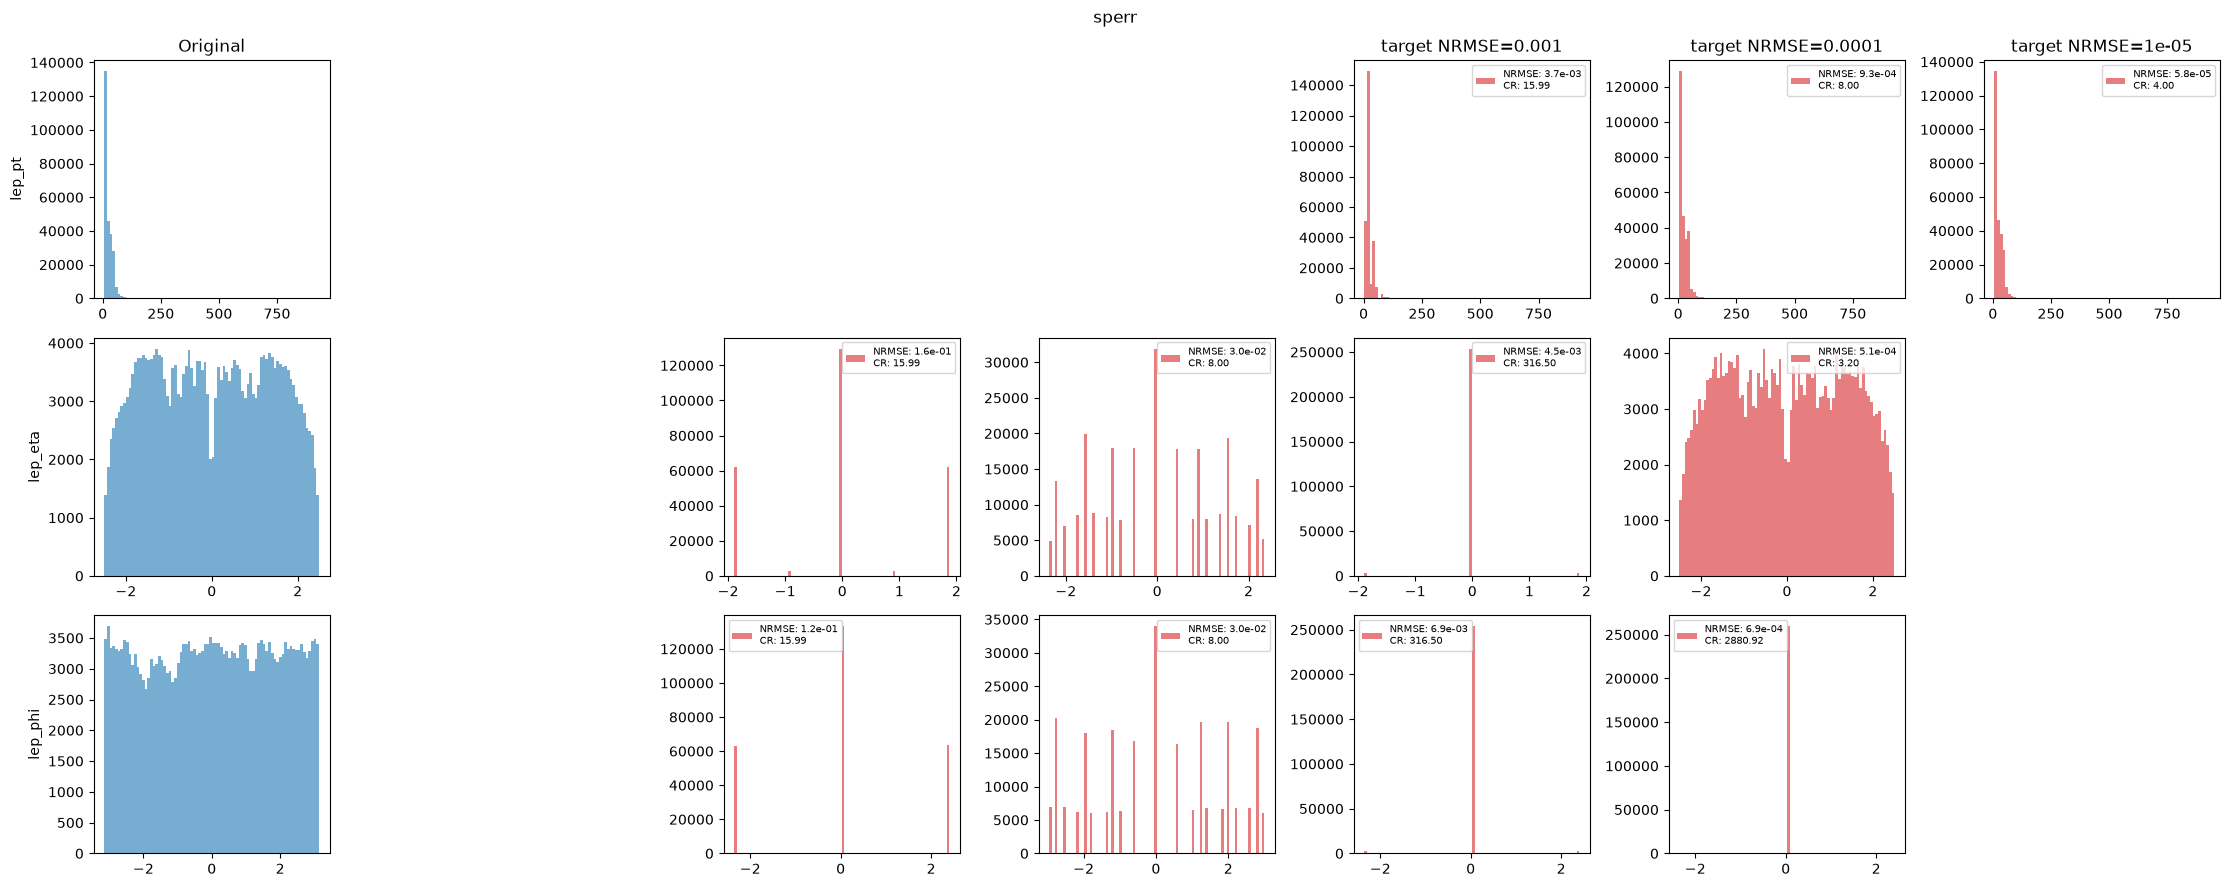

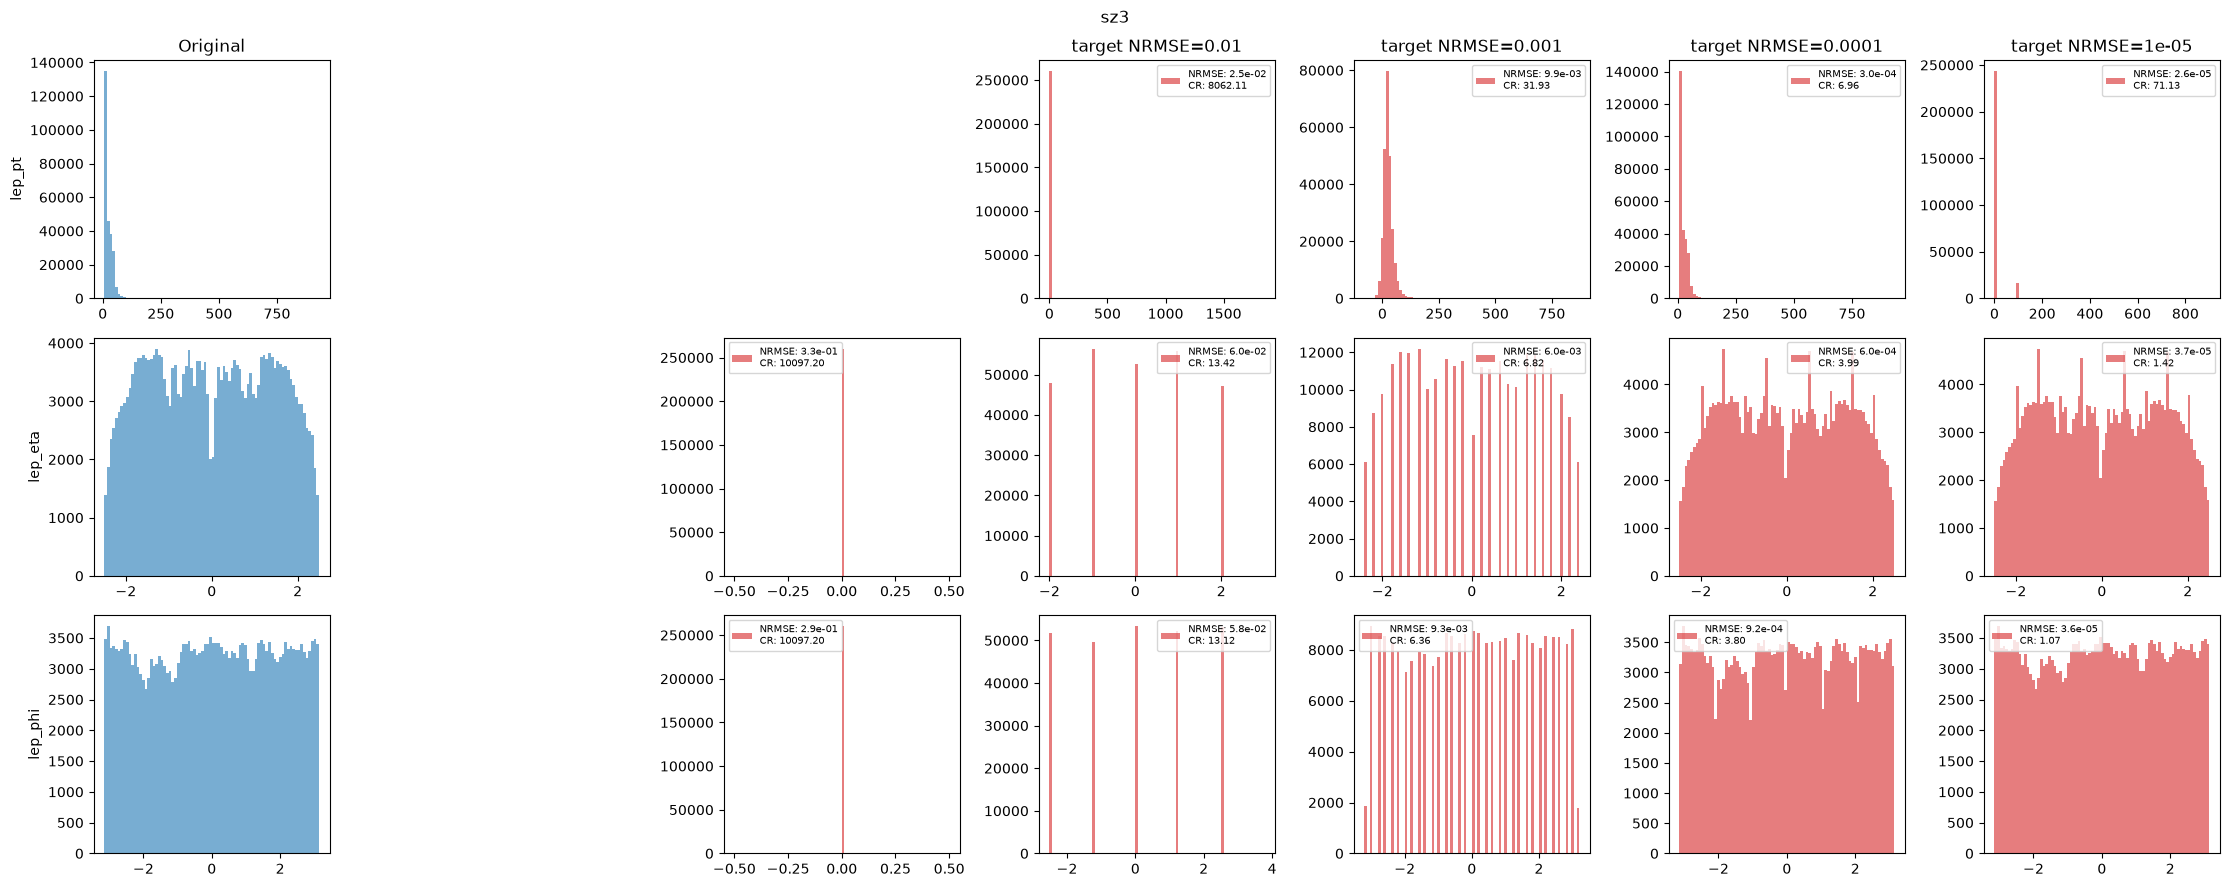

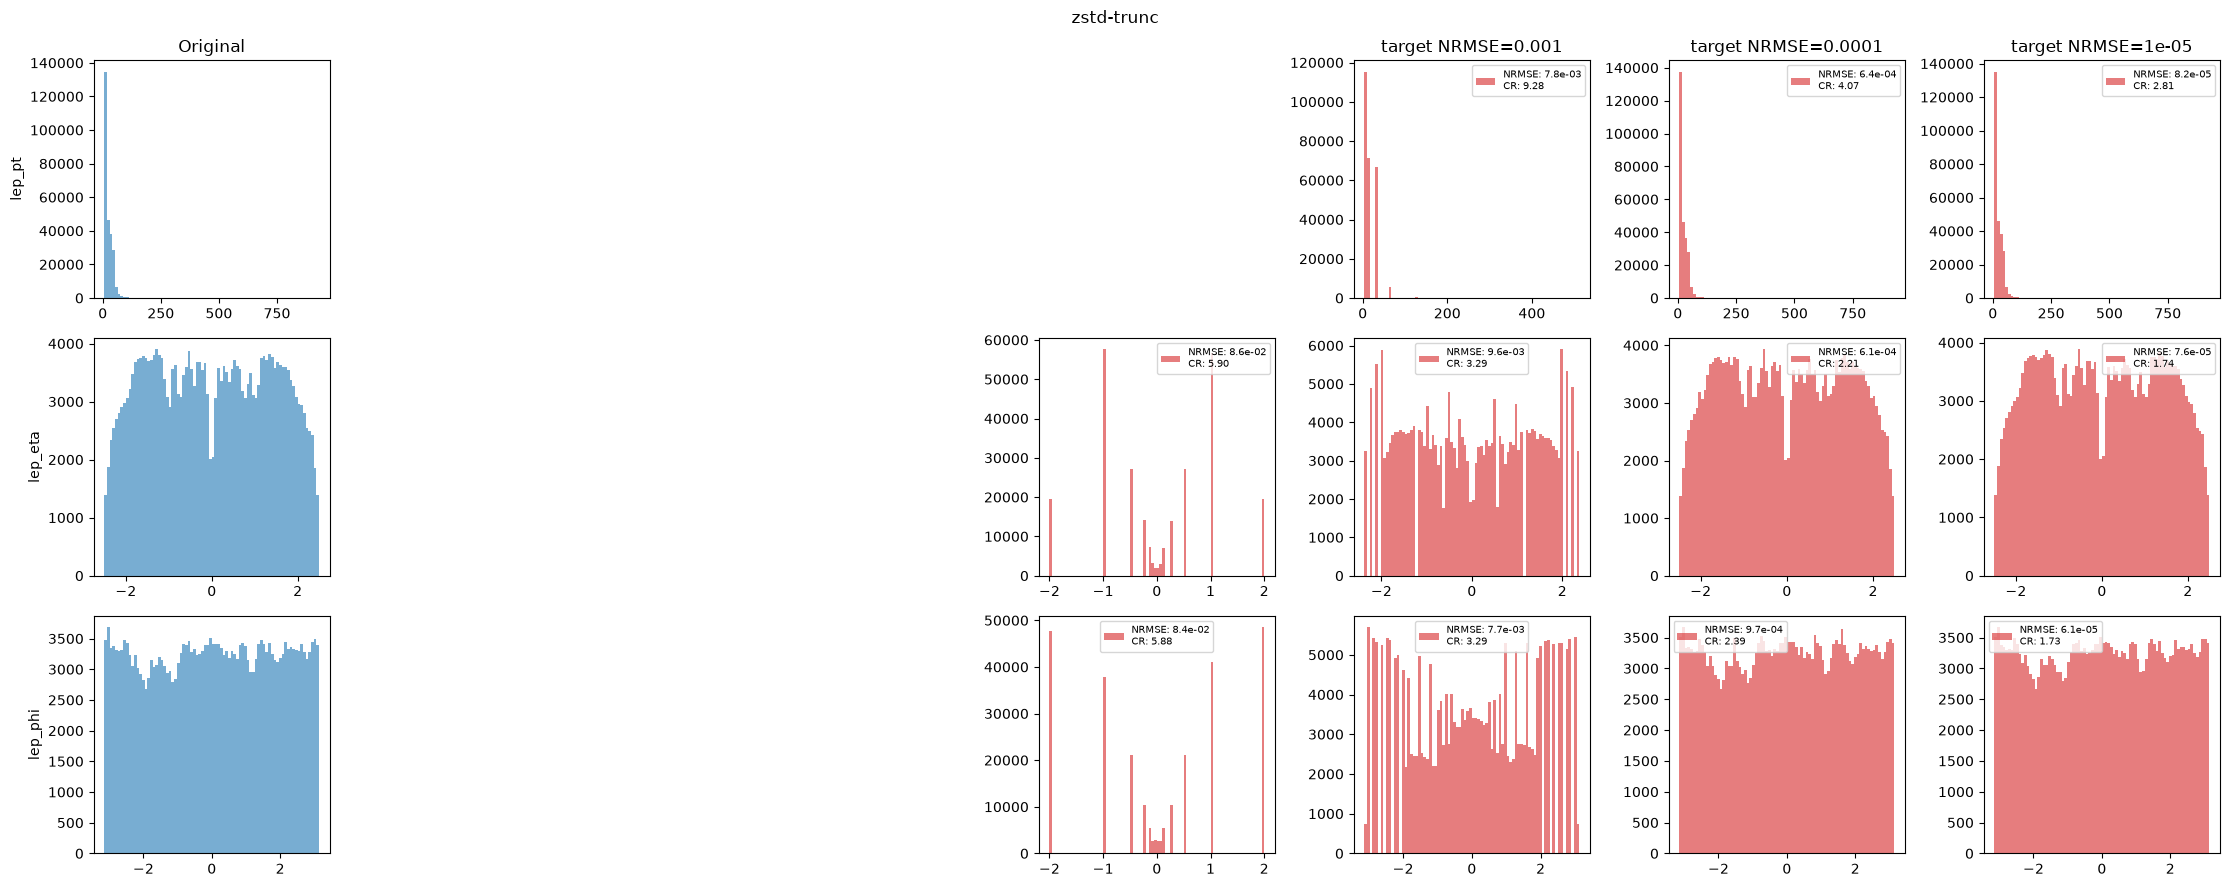

In [5]:
def decomp_file_for(compressor, target):
    return OUTDIR / f"decomp_{compressor}_target{target:g}.root"


orig_tree = uproot.open(MUONS_FILENAME)[MUONS_TREENAME]

for compressor in COMPRESSORS:
    fig, axes = plt.subplots(len(BRANCHES), len(TARGETS) + 1,
                              figsize=(3.2 * (len(TARGETS) + 1), 3 * len(BRANCHES)))

    for i, branch in enumerate(BRANCHES):
        lep_branch = f"lep_{branch}"
        og_data = orig_tree[lep_branch].array()

        axes[i, 0].hist(ak.flatten(og_data), bins=80, alpha=0.6, color="tab:blue")
        axes[i, 0].set_ylabel(lep_branch)
        if i == 0:
            axes[i, 0].set_title("Original")

        for j, target in enumerate(TARGETS):
            row = df[(df.branch == branch) & (df.compressor == compressor) & (df.target_nrmse == target)]
            ax = axes[i, j + 1]
            if row.empty:
                ax.axis("off")
                continue
            row = row.iloc[0]

            decomp_data = uproot.open(decomp_file_for(compressor, target))[MUONS_TREENAME][lep_branch].array()
            ax.hist(
                ak.flatten(decomp_data), bins=80, alpha=0.6, color="tab:red",
                label=f"NRMSE: {row['achieved_nrmse']:.1e}\nCR: {row['results.compression_ratio']:.2f}",
            )
            ax.legend(fontsize=7)
            if i == 0:
                ax.set_title(f"target NRMSE={target:g}")

    fig.suptitle(compressor)
    plt.tight_layout()
    plt.show()

All three compressors show `lep_pt` recovering its shape well before
`lep_eta`/`lep_phi` do, which makes sense given `lep_pt`'s value distribution
is naturally more compressible (heavily skewed toward small values, wide
dynamic range) than the roughly uniform `eta`/`phi`.

SZ3 and zstd-trunc otherwise degrade smoothly and predictably as the target
loosens. SPERR does not: at `target NRMSE=0.0001`, `lep_eta` and `lep_phi`
both collapse to a single spike, *more* destroyed than at the looser
`target NRMSE=0.001` (which merely discretizes them into $\sim$10 bins). The
cause is visible in the config table above — the best-compression point in
jet phi's [0.0001, 0.001) decade happened to be `quality=0.01` (SPERR's bpp
mode, so 0.01 *bits per value*, an extreme setting), while the
[0.001, 0.01) decade's best point was the much milder `quality=0.1`. Because
SPERR's bpp is an absolute bit-budget rather than an error bound scaled to
each branch's own range, "best compression in this decade" on jet phi doesn't
necessarily mean "best compression in this decade" on lepton phi, even though
both branches cover a similar range.

## Find the Z

Following [the ATLAS Open Data Find-the-Z notebook](https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/Find_the_Z.ipynb):
reconstruct the di-lepton invariant mass from each configuration's decompressed
`lep_pt`/`lep_eta`/`lep_phi`, combined with the *original* (uncompressed)
`lep_e`, and compare the resulting mass peak to the one from fully original
data.

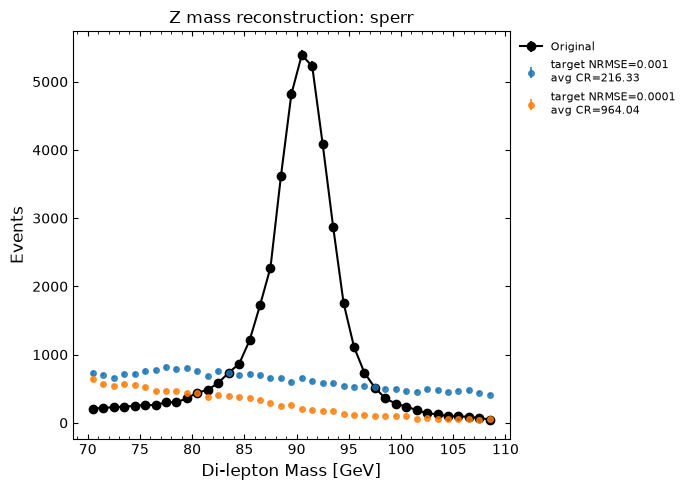

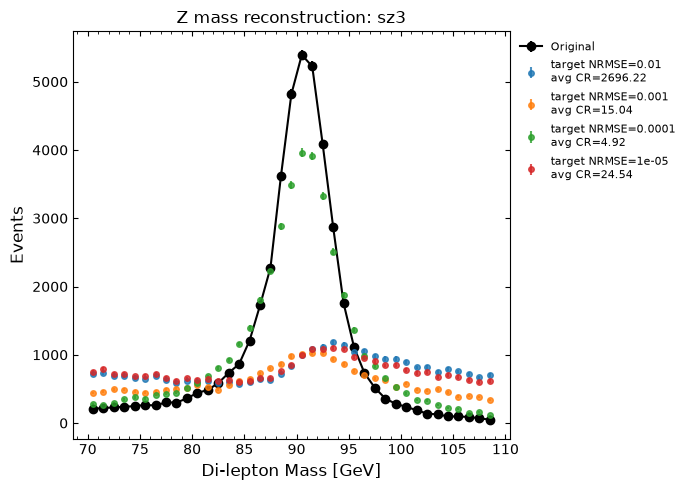

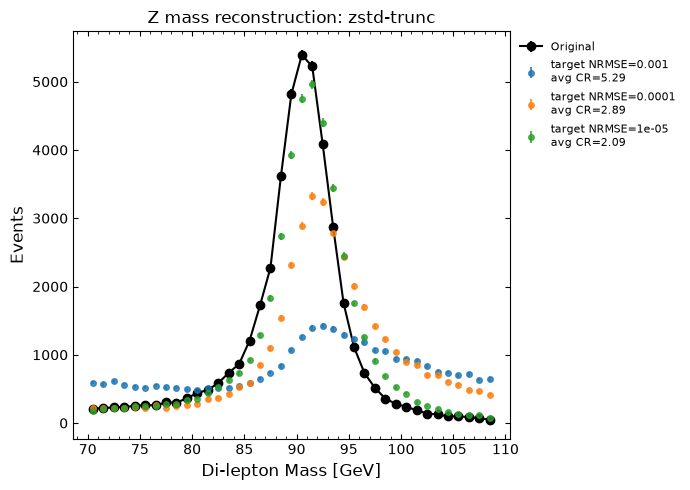

In [6]:
BIN_EDGES = np.arange(70, 110, 1)
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2


def invariant_mass_hist(pt, eta, phi, e):
    mask = ak.num(pt) == 2
    p4 = vector.zip({"pt": pt[mask], "eta": eta[mask], "phi": phi[mask], "e": e[mask]})
    mass = (p4[:, 0] + p4[:, 1]).M
    hist, _ = np.histogram(ak.to_numpy(mass), bins=BIN_EDGES)
    return hist


og = orig_tree.arrays(["lep_pt", "lep_eta", "lep_phi", "lep_e"])
hist_og = invariant_mass_hist(og.lep_pt, og.lep_eta, og.lep_phi, og.lep_e)

for compressor in COMPRESSORS:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(BIN_CENTERS, hist_og, yerr=np.sqrt(hist_og), fmt='o-',
                markersize=6, label="Original", color="black")

    for target in TARGETS:
        rows = df[(df.compressor == compressor) & (df.target_nrmse == target)]
        if len(rows) != len(BRANCHES):
            continue

        d = uproot.open(decomp_file_for(compressor, target))[MUONS_TREENAME].arrays(
            ["lep_pt", "lep_eta", "lep_phi"]
        )
        hist = invariant_mass_hist(d.lep_pt, d.lep_eta, d.lep_phi, og.lep_e)

        cr = rows["results.compression_ratio"].mean()
        label = f"target NRMSE={target:g}\navg CR={cr:.2f}"
        ax.errorbar(BIN_CENTERS, hist, yerr=np.sqrt(hist), fmt='o',
                    markersize=4, alpha=0.8, label=label)

    ax.set_xlabel("Di-lepton Mass [GeV]", fontsize=12)
    ax.set_ylabel("Events", fontsize=12)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.legend(frameon=False, fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    ax.set_title(f"Z mass reconstruction: {compressor}")
    plt.tight_layout()
    plt.show()

SZ3 and zstd-trunc degrade the mass peak monotonically as the NRMSE target
loosens: the tightest targets (NRMSE~$10^{-5}$/$10^{-4}$) track the original
peak closely — SZ3 reproduces it well even at target NRMSE=$10^{-5}$ with an
average compression ratio around 25x — NRMSE~$10^{-3}$ shows a visibly
broadened/shifted peak, and looser targets wash it out completely. That's the
expected behavior for a rate-distortion operating point carried over between
datasets, since both compressors' error bounds (`relErrorBound`, `truncBits`)
are defined relative to each value's own scale.

SPERR breaks that pattern for the reason explained above: its
`target NRMSE=0.0001` configuration destroys the peak almost completely (worse
than `target NRMSE=0.001`) because the best-compression point in that decade
for jet phi was an extreme, near-constant bpp setting that doesn't carry over
to lepton phi. This is a concrete illustration of why "best compression in
this distortion range" operating points chosen on one dataset need to be
checked, not just assumed, on the data they're actually meant to compress —
especially for a compressor whose quality knob (bits per value) isn't scaled
to the data's own range.